# Class 13
## Date: 19-04-2026

In [1]:
import pandas as pd
import numpy as np

In [2]:
df_s = pd.read_excel('../data/Student Grades.xlsx')
df_s

,Student,Class,Year,Grade
0,Emma,Freshman Seminar,Freshman,86.0
1,Olivia,Freshman Seminar,Freshman,86.0
2,Noah,Freshman Seminar,Freshman,86.0
3,Sophia,Freshman Seminar,Freshman,87.0
4,Liam,Freshman Seminar,Freshman,90.0
...,...,...,...,...
81,NaN,NaN,NaN,NaN
82,Bennett,NaN,NaN,NaN
83,NaN,EDA,Junior,84.0
84,Gavin,EDA,Senior,NaN


In [3]:
df_s[df_s.isna().any(axis=1)]

,Student,Class,Year,Grade
7,Jacob,Freshman Seminar,NaN,88.0
8,William,Freshman Seminar,NaN,89.0
9,Ethan,Freshman Seminar,NaN,86.0
62,Landon,Exploratory Data Analysis,Junior,NaN
81,NaN,NaN,NaN,NaN
82,Bennett,NaN,NaN,NaN
83,NaN,EDA,Junior,84.0
84,Gavin,EDA,Senior,NaN
85,Calvin,NaN,NaN,100.0


In [4]:
df_s['Class'].unique()

array(['Freshman Seminar', 'Intro to Python', 'Python', 'Intro to SQL',
       'Exploratory Data Analysis', 'EDA', nan], dtype=object)

In [5]:
df_s['Class'].nunique()

6

### **3. Inconsistent Text & Typos**

#### a. Find Inconsistent text and typos

In [6]:
df_r = pd.read_csv('../data/retail_2016_2017.csv')
df_r

,id,date,store_nbr,family,sales,onpromotion
0,1945944,2016-01-01,1,AUTOMOTIVE,0.000,0
1,1945945,2016-01-01,1,BABY CARE,0.000,0
2,1945946,2016-01-01,1,BEAUTY,0.000,0
3,1945947,2016-01-01,1,BEVERAGES,0.000,0
4,1945948,2016-01-01,1,BOOKS,0.000,0
...,...,...,...,...,...,...
1054939,3000883,2017-08-15,9,POULTRY,438.133,0
1054940,3000884,2017-08-15,9,PREPARED FOODS,154.553,1
1054941,3000885,2017-08-15,9,PRODUCE,2419.729,148
1054942,3000886,2017-08-15,9,SCHOOL AND OFFICE SUPPLIES,121.000,8


In [7]:
df_r.shape

(1054944, 6)

In [8]:
df_r.dtypes

id               int64
date            object
store_nbr        int64
family          object
sales          float64
onpromotion      int64
dtype: object

In [9]:
df_r['family'].nunique()

33

In [10]:
df_r['family'].value_counts()

family
AUTOMOTIVE                    31968
HOME APPLIANCES               31968
SCHOOL AND OFFICE SUPPLIES    31968
PRODUCE                       31968
PREPARED FOODS                31968
POULTRY                       31968
PLAYERS AND ELECTRONICS       31968
PET SUPPLIES                  31968
PERSONAL CARE                 31968
MEATS                         31968
MAGAZINES                     31968
LIQUOR,WINE,BEER              31968
LINGERIE                      31968
LAWN AND GARDEN               31968
LADIESWEAR                    31968
HOME CARE                     31968
HOME AND KITCHEN II           31968
BABY CARE                     31968
HOME AND KITCHEN I            31968
HARDWARE                      31968
GROCERY II                    31968
GROCERY I                     31968
FROZEN FOODS                  31968
EGGS                          31968
DELI                          31968
DAIRY                         31968
CLEANING                      31968
CELEBRATION          

In [11]:
df_r.describe()

,id,store_nbr,sales,onpromotion
count,1.054944e+06,1.054944e+06,1.054944e+06,1.054944e+06
mean,2.473416e+06,2.750000e+01,4.577225e+02,5.937977e+00
std,3.045362e+05,1.558579e+01,1.317155e+03,1.808632e+01
min,1.945944e+06,1.000000e+00,0.000000e+00,0.000000e+00
25%,2.209680e+06,1.400000e+01,2.000000e+00,0.000000e+00
50%,2.473416e+06,2.750000e+01,2.400000e+01,0.000000e+00
75%,2.737151e+06,4.100000e+01,2.620000e+02,3.000000e+00
max,3.000887e+06,5.400000e+01,1.247170e+05,7.410000e+02


#### b. Handling inconsistent text and typos 

In [12]:
df_s['Class'].value_counts()

Class
Intro to Python              25
Intro to SQL                 20
EDA                          13
Freshman Seminar             12
Exploratory Data Analysis    12
Python                        1
Name: count, dtype: int64

In [13]:
df_s['Class'] = np.where(df_s['Class'] == 'Intro to Python' , 'Python', df_s['Class'])
df_s['Class'] = np.where(df_s['Class'] == 'Intro to SQL' , 'SQL', df_s['Class'])
df_s['Class'] = np.where(df_s['Class'] == 'Exploratory Data Analysis' , 'EDA', df_s['Class'])
df_s['Class'] = np.where(df_s['Class'] == 'Freshman Seminar' , 'FS', df_s['Class'])

In [14]:
df_s['Class'].value_counts()

Class
Python    26
EDA       25
SQL       20
FS        12
Name: count, dtype: int64

array([[<Axes: title={'center': 'Grade'}>]], dtype=object)

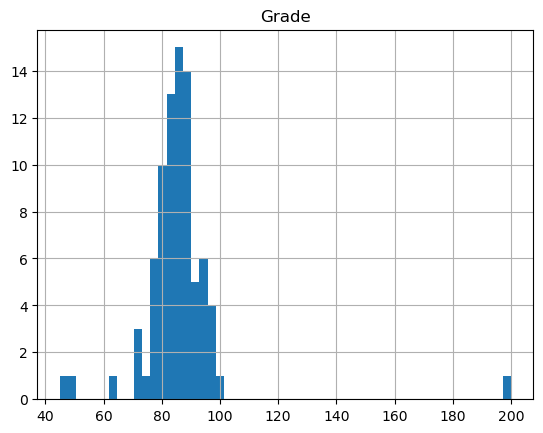

In [15]:
df_s.hist(bins=55)

In [16]:
df_s[df_s['Grade'] <= 100]
df_s['Grade'] = np.where(df_s['Grade'] > 100, 100, df_s['Grade']) #it will replace 200 outlier

In [17]:
# diff b/w min and max
df_s.Grade.max() - df_s.Grade.min()

55.0

array([[<Axes: title={'center': 'Grade'}>]], dtype=object)

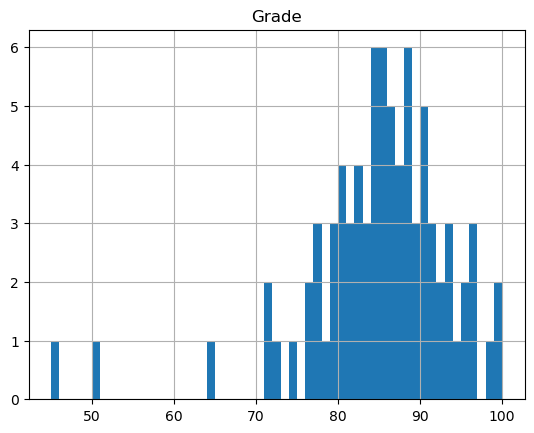

In [18]:
df_s.hist(bins=55) # (bins is max - min , here 100-45)

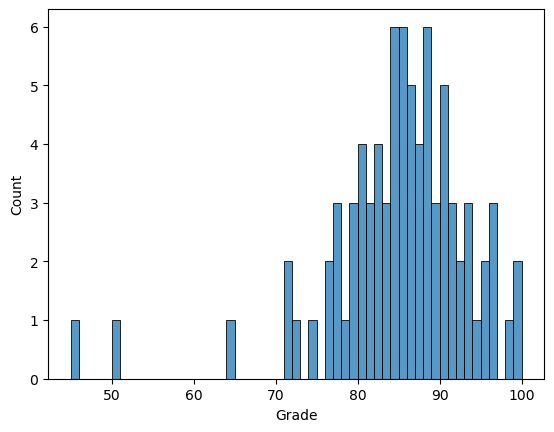

In [19]:
import seaborn as sns
sns.histplot(df_s['Grade'], binwidth=1);

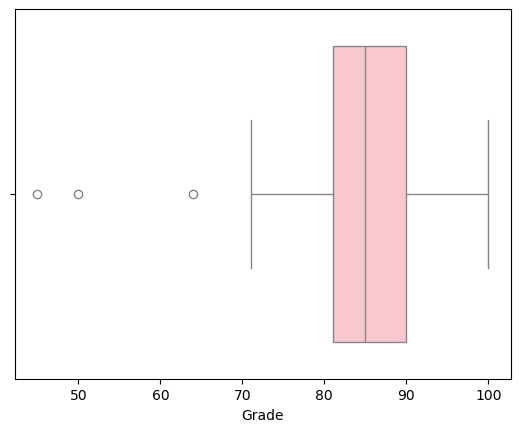

In [20]:
sns.boxplot(x=df_s['Grade'], color= 'pink' );

### **4. Find Outlier**

#### _STDEV_

In [21]:
mean = np.mean(df_s['Grade'])
sd = np.std(df_s['Grade'])

#show both
mean , sd

(np.float64(84.48780487804878), 8.93642027752509)

In [22]:
# identify points that are more than 2 sd away
[grade for grade in df_s['Grade'] if (grade<mean-2*sd)or
(grade > mean + 2*sd)]

[50.0, 45.0, 64.0]

In [23]:
# identify points that are more than 3 sd away
[grade for grade in df_s['Grade'] if (grade<mean-3*sd)or
(grade > mean + 3*sd)]

[50.0, 45.0]

In [24]:
df_s = df_s.dropna(subset=['Grade'])
print(df_s['Grade'].isnull().sum()) 

0


In [25]:
q25, q50, q75= np.percentile(df_s['Grade'], [25,50,75])
iqr= q75-q25

min_grade = q25 - 1.5*iqr
max_grade = q25 + 1.5*iqr

min_grade, q25, q50, q75, max_grade, iqr

(np.float64(67.5),
 np.float64(81.0),
 np.float64(85.0),
 np.float64(90.0),
 np.float64(94.5),
 np.float64(9.0))

### **5. Duplicate Rows**

#### a. Find duplicate rows

In [26]:
df_s.head()

,Student,Class,Year,Grade
0,Emma,FS,Freshman,86.0
1,Olivia,FS,Freshman,86.0
2,Noah,FS,Freshman,86.0
3,Sophia,FS,Freshman,87.0
4,Liam,FS,Freshman,90.0


In [27]:
df_s.duplicated()

0     False
1     False
2     False
3     False
4     False
      ...  
78    False
79    False
80    False
83    False
85    False
Length: 82, dtype: bool

In [28]:
df_s[df_s.duplicated()] #it doesnt consider 1st one as duplicate (so out of 3 same val 2 will be duplicate)

,Student,Class,Year,Grade
19,Mia,Python,Freshman,80.0
43,Isaac,SQL,Sophomore,96.0
44,Isaac,SQL,Sophomore,96.0


In [29]:
df_s[df_s['Student'] == 'Isaac']

,Student,Class,Year,Grade
42,Isaac,SQL,Sophomore,96.0
43,Isaac,SQL,Sophomore,96.0
44,Isaac,SQL,Sophomore,96.0


In [30]:
df_s[df_s['Student'] == 'Mia']

,Student,Class,Year,Grade
18,Mia,Python,Freshman,80.0
19,Mia,Python,Freshman,80.0


In [31]:
df_dup = df_s.drop_duplicates()

In [32]:
df_dup[df_dup.duplicated(keep=False)]

,Student,Class,Year,Grade


In [33]:
df_s[df_s.duplicated(keep=False)]

,Student,Class,Year,Grade
18,Mia,Python,Freshman,80.0
19,Mia,Python,Freshman,80.0
42,Isaac,SQL,Sophomore,96.0
43,Isaac,SQL,Sophomore,96.0
44,Isaac,SQL,Sophomore,96.0


In [34]:
df_dup[df_dup['Student'] == 'Mia']

,Student,Class,Year,Grade
18,Mia,Python,Freshman,80.0


In [35]:
df_dup[df_dup['Student'] == 'Isaac']

,Student,Class,Year,Grade
42,Isaac,SQL,Sophomore,96.0


# **EDA**

### **6. Create new columns from numeric columns**

In [36]:
groc = pd.read_excel('../data/Groceries.xlsx')
groc.head()

,Product_ID,Category,Item,Price_Dollars,Inventory,Last_Updated,Next_Scheduled_Shipment
0,P100010,Produce: Fruit,Apple,1.50,349,2023-06-12 15:35:00,2023-06-15
1,P100011,Produce: Fruit,Banana,0.40,500,2023-06-12 18:30:00,2023-06-15
2,P100012,Produce: Fruit,Grapes,4.00,200,2023-06-12 17:22:00,2023-06-15
3,P100013,Produce: Fruit,Grapefruit,0.99,50,2023-06-12 16:29:00,2023-06-15
4,P100014,Produce: Fruit,Organic Strawberries,3.99,148,2023-06-12 18:10:00,2023-06-15


In [37]:
groc.shape

(25, 7)

In [38]:
groc.dtypes

Product_ID                         object
Category                           object
Item                               object
Price_Dollars                     float64
Inventory                           int64
Last_Updated               datetime64[ns]
Next_Scheduled_Shipment    datetime64[ns]
dtype: object

In [39]:
groc.describe()

,Price_Dollars,Inventory,Last_Updated,Next_Scheduled_Shipment
count,25.000000,25.000000,25,25
mean,4.266400,194.280000,2023-06-10 04:18:40.800000,2023-06-19 01:55:12
min,0.400000,5.000000,2023-05-28 22:02:00,2023-06-15 00:00:00
25%,1.780000,78.000000,2023-06-10 12:24:00,2023-06-15 00:00:00
50%,3.500000,178.000000,2023-06-12 17:47:00,2023-06-17 00:00:00
75%,5.990000,284.000000,2023-06-13 07:00:00,2023-06-24 00:00:00
max,10.990000,500.000000,2023-06-13 08:54:00,2023-06-28 00:00:00
std,3.104263,139.015743,NaN,NaN


In [40]:
groc.isnull().sum()

Product_ID                 0
Category                   0
Item                       0
Price_Dollars              0
Inventory                  0
Last_Updated               0
Next_Scheduled_Shipment    0
dtype: int64

In [41]:
groc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Product_ID               25 non-null     object        
 1   Category                 25 non-null     object        
 2   Item                     25 non-null     object        
 3   Price_Dollars            25 non-null     float64       
 4   Inventory                25 non-null     int64         
 5   Last_Updated             25 non-null     datetime64[ns]
 6   Next_Scheduled_Shipment  25 non-null     datetime64[ns]
dtypes: datetime64[ns](2), float64(1), int64(1), object(3)
memory usage: 1.5+ KB


In [42]:
groc.nunique()

Product_ID                 25
Category                    7
Item                       25
Price_Dollars              23
Inventory                  23
Last_Updated               25
Next_Scheduled_Shipment     4
dtype: int64

In [43]:
groc['Category'].unique()

array(['Produce: Fruit', 'Produce: Vegetable', 'Produce: Meat',
       'Produce: Dairy', 'Pantry: Snacks', 'Frozen: Frozen Snacks',
       'Frozen: Frozen Fruit'], dtype=object)

In [44]:
groc.value_counts()

Product_ID  Category               Item                   Price_Dollars  Inventory  Last_Updated         Next_Scheduled_Shipment
P100010     Produce: Fruit         Apple                  1.50           349        2023-06-12 15:35:00  2023-06-15                 1
P100023     Produce: Dairy         Butter                 3.50           400        2023-06-13 08:35:00  2023-06-17                 1
P100033     Frozen: Frozen Fruit   Frozen Blueberries     10.99          162        2023-05-28 22:14:00  2023-06-28                 1
P100032     Frozen: Frozen Snacks  Spinach Dip            4.96           76         2023-05-28 22:05:00  2023-06-28                 1
P100031     Frozen: Frozen Snacks  Chicken Nuggets        6.99           85         2023-05-28 22:02:00  2023-06-28                 1
P100030     Pantry: Snacks         Raisins                2.99           5          2023-06-10 12:38:00  2023-06-24                 1
P100029     Pantry: Snacks         Cookies (Oatmeal)      5.39     

In [45]:
groc['Category'].value_counts()

Category
Produce: Fruit           6
Produce: Vegetable       4
Produce: Dairy           4
Pantry: Snacks           4
Produce: Meat            3
Frozen: Frozen Snacks    2
Frozen: Frozen Fruit     2
Name: count, dtype: int64

In [46]:
groc[groc['Inventory'] <= 50]

,Product_ID,Category,Item,Price_Dollars,Inventory,Last_Updated,Next_Scheduled_Shipment
3,P100013,Produce: Fruit,Grapefruit,0.99,50,2023-06-12 16:29:00,2023-06-15
8,P100018,Produce: Vegetable,Celery,1.99,50,2023-06-12 16:42:00,2023-06-15
15,P100025,Produce: Dairy,Milk (Soy),4.49,32,2023-06-13 08:37:00,2023-06-17
17,P100027,Pantry: Snacks,Apple Sauce - organic,1.50,27,2023-06-10 12:02:00,2023-06-24
20,P100030,Pantry: Snacks,Raisins,2.99,5,2023-06-10 12:38:00,2023-06-24


In [53]:
groc['Stock'] = np.where(groc['Inventory'] <= 50, 'Low Inventory', 'Good')
groc['New_Price'] = groc['Price_Dollars'] * 1.05
groc['Product_No'] = groc['Product_ID'].str.replace('P', '').astype(int) #remember if null val it will not convert (then use pd.to_numeric)
groc['Total_Inventory'] = groc['Inventory'].sum()
groc['Inventory_Share'] = (groc['Inventory']/groc['Total_Inventory'])*100

In [54]:
groc.head()

,Product_ID,Category,Item,Price_Dollars,Inventory,Last_Updated,Next_Scheduled_Shipment,Stock,New_Price,Product_No,Total_Inventory,Inventory_Share,last_updated_month
0,P100010,Produce: Fruit,Apple,1.50,349,2023-06-12 15:35:00,2023-06-15,Good,1.5750,100010,4857,7.185505,2023
1,P100011,Produce: Fruit,Banana,0.40,500,2023-06-12 18:30:00,2023-06-15,Good,0.4200,100011,4857,10.294420,2023
2,P100012,Produce: Fruit,Grapes,4.00,200,2023-06-12 17:22:00,2023-06-15,Good,4.2000,100012,4857,4.117768,2023
3,P100013,Produce: Fruit,Grapefruit,0.99,50,2023-06-12 16:29:00,2023-06-15,Low Inventory,1.0395,100013,4857,1.029442,2023
4,P100014,Produce: Fruit,Organic Strawberries,3.99,148,2023-06-12 18:10:00,2023-06-15,Good,4.1895,100014,4857,3.047148,2023


In [55]:
groc.dtypes

Product_ID                         object
Category                           object
Item                               object
Price_Dollars                     float64
Inventory                           int64
Last_Updated               datetime64[ns]
Next_Scheduled_Shipment    datetime64[ns]
Stock                              object
New_Price                         float64
Product_No                          int64
Total_Inventory                     int64
Inventory_Share                   float64
last_updated_month                  int32
dtype: object

In [56]:
groc['last_updated_month'] = groc['Last_Updated'].dt.year

In [57]:
groc.head()

,Product_ID,Category,Item,Price_Dollars,Inventory,Last_Updated,Next_Scheduled_Shipment,Stock,New_Price,Product_No,Total_Inventory,Inventory_Share,last_updated_month
0,P100010,Produce: Fruit,Apple,1.50,349,2023-06-12 15:35:00,2023-06-15,Good,1.5750,100010,4857,7.185505,2023
1,P100011,Produce: Fruit,Banana,0.40,500,2023-06-12 18:30:00,2023-06-15,Good,0.4200,100011,4857,10.294420,2023
2,P100012,Produce: Fruit,Grapes,4.00,200,2023-06-12 17:22:00,2023-06-15,Good,4.2000,100012,4857,4.117768,2023
3,P100013,Produce: Fruit,Grapefruit,0.99,50,2023-06-12 16:29:00,2023-06-15,Low Inventory,1.0395,100013,4857,1.029442,2023
4,P100014,Produce: Fruit,Organic Strawberries,3.99,148,2023-06-12 18:10:00,2023-06-15,Good,4.1895,100014,4857,3.047148,2023
